# Анализ результатов A/B-теста

В этом проекте произведен анализ результатов A/B-теста новой версии сайта интернет-магазина.

Пользователи были разделены на две группы:
- **C (control)** — пользователи, которые видели старую версию сайта;
- **V1 (test)** — пользователи, которые видели новую версию.

Основная метрика эксперимента - **конверсия в покупку**.

Цель анализа - проверить, изменилась ли конверсия, после запуска новой версии, и понять, есть ли основания выкатывать её на всех пользователей.

## 1. Проверка данных

Проверка структуры и качества данных перед анализом результатов эксперимента.

In [179]:
import pandas as pd
import matplotlib.pyplot as plt

from statsmodels.stats.proportion import proportions_ztest

In [180]:
df = pd.read_csv("../data/ecommerce_conversion_ab_test_data.csv")

df.head()

,TvC,date,traffic_source,device_type,browser_language,login_y_n,region,return_y_n,conversion
0,C,2021-02-14,Referrals,Mweb,Chinese,n,Southwest,y,1
1,C,2021-02-14,Direct,Iphone,English,y,West,y,0
2,C,2021-02-11,Email Marketing,Mweb,English,y,Northeast,y,0
3,C,2021-02-11,Referrals,Iphone,English,y,Southwest,n,0
4,C,2021-02-01,Referrals,Desktop,English,y,Northeast,n,0


In [181]:
df.shape

(2000000, 9)

In [182]:
df.info()

<class 'pandas.core.frame.DataFrame'>
RangeIndex: 2000000 entries, 0 to 1999999
Data columns (total 9 columns):
 #   Column            Dtype 
---  ------            ----- 
 0   TvC               object
 1   date              object
 2   traffic_source    object
 3   device_type       object
 4   browser_language  object
 5   login_y_n         object
 6   region            object
 7   return_y_n        object
 8   conversion        int64 
dtypes: int64(1), object(8)
memory usage: 137.3+ MB


In [183]:
df.isna().sum()

TvC                 0
date                0
traffic_source      0
device_type         0
browser_language    0
login_y_n           0
region              0
return_y_n          0
conversion          0
dtype: int64

In [184]:
df.duplicated().sum()

np.int64(1895422)

In [185]:
for column in ['TvC', 'device_type', 'login_y_n', 'return_y_n', 'conversion']:
    print(column, df[column].unique())

TvC ['C' 'V1']
device_type ['Mweb' 'Iphone' 'Desktop' 'Android']
login_y_n ['n' 'y']
return_y_n ['y' 'n']
conversion [1 0]


In [186]:
df['date'] = pd.to_datetime(df['date'])

df['date'].min(), df['date'].max()

(Timestamp('2021-02-01 00:00:00'), Timestamp('2021-02-16 00:00:00'))

В датасете 2 млн наблюдений за период с 1 по 16 февраля 2021 года. Пропущенных значений нет, значения основных категориальных признаков корректны.

Большая часть строк имеет полные совпадения по всем признакам. При этом в данных нет идентификатора пользователя, поэтому определить, являются ли такие строки реальными дубликатами, невозможно. Удалять их из анализа без дополнительных оснований не стоит.

## 2. Результаты эксперимента

### Распределение наблюдений по группам

In [187]:
df['TvC'].value_counts()

TvC
C     1000000
V1    1000000
Name: count, dtype: int64

In [188]:
df['TvC'].value_counts(normalize=True)

TvC
C     0.5
V1    0.5
Name: proportion, dtype: float64

### Конверсия по группам

In [189]:
conversion_by_group = df.groupby('TvC')['conversion'].agg(['count', 'sum', 'mean'])
conversion_by_group

,count,sum,mean
TvC,,,
C,1000000,100092,0.100092
V1,1000000,109884,0.109884


In [190]:
control_conversion = conversion_by_group.loc['C', 'mean']
test_conversion = conversion_by_group.loc['V1', 'mean']

absolute_uplift = test_conversion - control_conversion
relative_uplift = absolute_uplift / control_conversion

print(f'Конверсия C: {control_conversion:.2%}')
print(f'Конверсия V1: {test_conversion:.2%}')
print(f'Абсолютный прирост: {absolute_uplift * 100:.2f} п.п.')
print(f'Относительный прирост: {relative_uplift:.2%}')

Конверсия C: 10.01%
Конверсия V1: 10.99%
Абсолютный прирост: 0.98 п.п.
Относительный прирост: 9.78%


Конверсия в тестовой группе составила **10,99%** против **10,01%** в контрольной. Наблюдаемый прирост — **0,98 п.п.**, или **9,78%** относительно контрольной группы.

Чтобы определить, можно ли считать эту разницу результатом изменения версии сайта, необходимо проверить её статистическую значимость.

## 3. Проверка статистической значимости

Необходимо проверить является ли разница в конверсии между группами статистически значимой.

- **H₀:** конверсия в группах C и V1 не различается.
- **H₁:** конверсия в группах C и V1 различается.

Уровень значимости: **α = 0,05**.

In [191]:
conversions = [100092, 109884]
observations = [1000000, 1000000]

z_stat, p_value = proportions_ztest(conversions, observations)

print(f'z-статистика: {z_stat:.2f}')
print(f'p-value: {p_value:.4f}')

z-статистика: -22.59
p-value: 0.0000


Полученное p-value < 0,001, поэтому на уровне значимости 5% нулевая гипотеза отвергается. Разница в конверсии между группами статистически значима.

Конверсия в V1 составила **10,99%** против **10,01%** в контрольной группе. Абсолютный прирост — **0,98 п.п.**, относительный — **9,78%**.

Таким образом, по результатам эксперимента новая версия показывает статистически значимое увеличение конверсии.

## 4. Оценка размера эффекта

95% доверительный интервал позволяет оценить диапазон возможных значений эффекта новой версии относительно контрольной группы.

In [192]:
from statsmodels.stats.proportion import confint_proportions_2indep

ci_low, ci_high = confint_proportions_2indep(
    109884, 1000000,
    100092, 1000000,
    method='wald'
)

print(f'95% ДИ: [{ci_low * 100:.2f}; {ci_high * 100:.2f}] п.п.')

95% ДИ: [0.89; 1.06] п.п.


Оценка прироста конверсии составляет **0,98 п.п.** 95% доверительный интервал для разницы между V1 и C — **[0,89; 1,06] п.п.**

Интервал полностью находится выше нуля, что подтверждает положительный эффект новой версии и согласуется с результатом статистического теста.

## 5. Сегментный анализ

Сравнение конверсии C и V1 по типу устройства и статусу пользователя позволяет проверить, сохраняется ли общий эффект новой версии в отдельных сегментах.

### 5.1 По типу устройства

Конверсия и абсолютный прирост V1 относительно C для каждого типа устройства.

In [193]:
device_conversion = (
    df.groupby(['device_type', 'TvC'])['conversion']
    .mean()
    .unstack()
)

device_conversion['uplift_pp'] = (device_conversion['V1'] - device_conversion['C']) * 100

device_conversion

TvC,C,V1,uplift_pp
device_type,,,
Android,0.100601,0.111735,1.113374
Desktop,0.099367,0.110157,1.079057
Iphone,0.100079,0.109901,0.982265
Mweb,0.100287,0.109354,0.906680


Положительный эффект V1 сохраняется на всех типах устройств. Наибольший прирост наблюдается на **Android (+1,11 п.п.)** и **Desktop (+1,08 п.п.)**, наименьший — на **Mweb (+0,91 п.п.)**.

Направление эффекта одинаково во всех сегментах по типу устройства: ни в одном из них новая версия не показывает снижение конверсии.

### 5.2 Новые и вернувшиеся пользователи

Сравнение эффекта новой версии для новых и вернувшихся пользователей.

In [194]:
return_conversion = (
    df.groupby(['return_y_n', 'TvC'])['conversion']
    .mean()
    .unstack()
)

return_conversion['uplift_pp'] = (return_conversion['V1'] - return_conversion['C']) * 100

return_conversion

TvC,C,V1,uplift_pp
return_y_n,,,
n,0.100126,0.109816,0.968988
y,0.100069,0.109929,0.986014



Наблюдаемый эффект практически одинаков для новых и вернувшихся пользователей: **+0,97 п.п.** и **+0,99 п.п.** соответственно.

В обоих сегментах направление и величина эффекта близки, поэтому общий рост конверсии не объясняется только одной из групп пользователей.

## 6. Визуализация результатов

### Конверсия C и V1

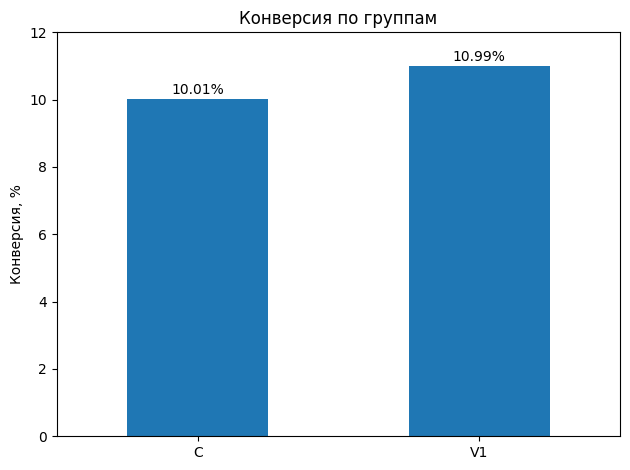

In [195]:
conversion_rates = conversion_by_group['mean'] * 100

ax = conversion_rates.plot(kind='bar')

ax.set_title('Конверсия по группам')
ax.set_xlabel('')
ax.set_ylabel('Конверсия, %')
ax.set_ylim(0, 12)

for i, value in enumerate(conversion_rates):
    ax.text(i, value + 0.15, f'{value:.2f}%', ha='center')

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../images/conversion_by_group.png', dpi=150)
plt.show()

### Прирост конверсии по типу устройства

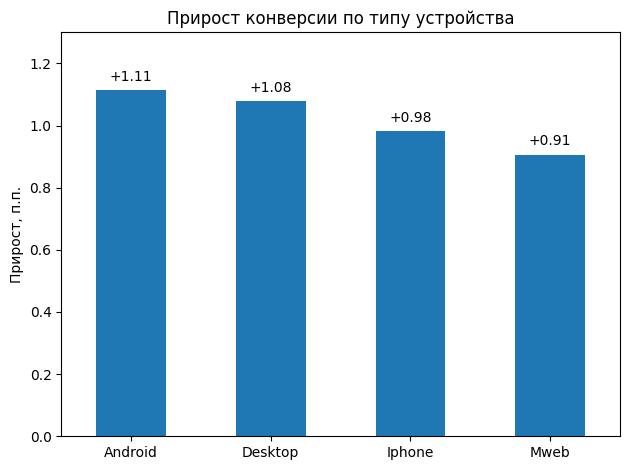

In [196]:
device_uplift = device_conversion['uplift_pp'].sort_values(ascending=False)

ax = device_uplift.plot(kind='bar')

ax.set_title('Прирост конверсии по типу устройства')
ax.set_xlabel('')
ax.set_ylabel('Прирост, п.п.')
ax.set_ylim(0, 1.3)

for i, value in enumerate(device_uplift):
    ax.text(i, value + 0.03, f'+{value:.2f}', ha='center')

plt.xticks(rotation=0)
plt.tight_layout()
plt.savefig('../images/uplift_by_device.png', dpi=150)
plt.show()

## 7. Итоговый вывод

Новая версия V1 увеличила конверсию с **10,01% до 10,99%**. Абсолютный прирост составил **+0,98 п.п.**, относительный — **+9,78%**.

Разница статистически значима (**p-value < 0,001**). 95% доверительный интервал для эффекта составляет **[0,89; 1,06] п.п.** и полностью находится выше нуля.

Положительный эффект наблюдается на всех типах устройств, а также отдельно для новых и вернувшихся пользователей. В рассмотренных сегментах направление эффекта сохраняется.

По основной метрике V1 показывает устойчивое преимущество перед контрольной версией. При принятии решения о полном запуске необходимо также учитывать защитные метрики продукта. В представленном датасете отсутствуют данные о выручке, отказах, скорости загрузки и других возможных guardrail-метриках, поэтому решение о внедрении новой версии только на основании конверсии было бы неполным..

Дополнительное ограничение анализа — отсутствие id пользователя. Это не позволяет проверить уникальность пользователей и корректность распределения наблюдений между экспериментальными группами на уровне пользователя.